In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("WIPRO.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,WIPRO,EQ,2522.40,2724.00,2724.20,2724.00,2724.20,2724.20,2724.17,1599,4.355942e+11,NaN,NaN,NaN
1,2000-01-04,WIPRO,EQ,2724.20,2942.15,2942.15,2942.15,2942.15,2942.15,2942.15,4392,1.292192e+12,NaN,NaN,NaN
2,2000-01-05,WIPRO,EQ,2942.15,2942.15,3177.55,2715.00,3000.00,2990.10,3063.86,132297,4.053390e+13,NaN,NaN,NaN
3,2000-01-06,WIPRO,EQ,2990.10,3144.70,3183.00,2790.00,2915.00,2932.25,2962.41,72840,2.157822e+13,NaN,NaN,NaN
4,2000-01-07,WIPRO,EQ,2932.25,2751.00,2751.00,2697.70,2697.70,2697.70,2697.95,10110,2.727630e+12,NaN,NaN,NaN


In [3]:
data = df['Close'].values
data = data.reshape(-1,1)

In [4]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [5]:
def create_dataset(data, time_step=10):
    X, y = [], []
    
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
        
    return np.array(X), np.array(y)

time_step = 10

X, y = create_dataset(data_scaled, time_step)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,shuffle=False)

In [7]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [8]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

/Users/dnyaneshwari/Desktop/LABS/SEM_VI/DLML/py39_env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics = ["accuracy"])

In [21]:
history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_test, y_test))

Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 4.1700e-04 - loss: 6.3175e-05 - val_accuracy: 9.4429e-04 - val_loss: 3.2353e-06
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 3.3535e-05 - loss: 4.6971e-05 - val_accuracy: 9.4429e-04 - val_loss: 1.7749e-06
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0010 - loss: 5.5978e-05 - val_accuracy: 9.4429e-04 - val_loss: 1.7653e-06
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 2.5663e-05 - loss: 4.7661e-05 - val_accuracy: 9.4429e-04 - val_loss: 2.4247e-06
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 2.5279e-04 - loss: 4.5696e-05 - val_accuracy: 9.4429e-04 - val_loss: 3.7914e-06
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 3.3854e-04 - loss: 4.3280e-05 - val_accuracy: 9.4429e-04 - val_loss: 4.9571e-06
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.5067e-04 - loss: 6.1021e-05 - val_accuracy: 9.4429e-04 - val_loss: 1.3004

In [22]:
def plot_results(history):
    results = pd.DataFrame({"Train Loss": history.history['loss'], "Validation Loss": history.history['val_loss'],
              "Train Accuracy": history.history['accuracy'], "Validation Accuracy": history.history['val_accuracy']
             })
    fig, ax = plt.subplots(nrows=2, figsize=(16, 9))
    results[["Train Loss", "Validation Loss"]].plot(ax=ax[0])
    results[["Train Accuracy", "Validation Accuracy"]].plot(ax=ax[1])
    ax[0].set_xlabel("Epoch")
    ax[1].set_xlabel("Epoch")
    plt.show()

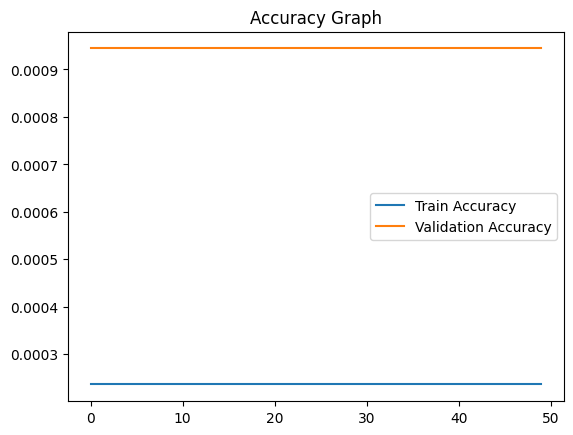

In [23]:
#acc visualization
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

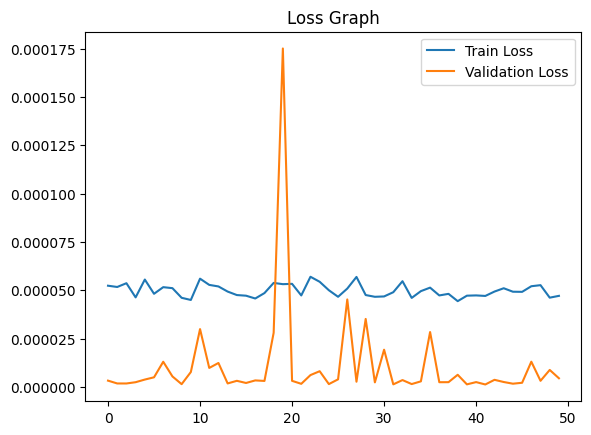

In [24]:
#loss visualization
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()